# Adam
Paper Link: (https://arxiv.org/abs/1412.6980)

- The *Adam* method calculates individual adaptive rates based on first and second moments (mean and variance) of the gradients
- Some of its selling points:
    - It is immune to rescaling of the gradient. If the the gradient becomes 10 times larger than the magnitude of parameter update will be about the same anyway.
        - I don't fully see how this is helpful
     - The step sizes are bounded
     - It works for sparse gradients
     - It performs natural step size annealing (slows down learning rate when we get closer to the goal)

### Pseudocode
Requires $\alpha$, $\beta_1,\beta_2 \in [0,1)$ exponential decay rates, $f(\theta)$ objective functions, $\theta_0$ initial parameters

Initialize $m_0, v_0, t$ to $0$ 

---
While $\theta_t$ not converged **do**:

Increment Timestep: $t \leftarrow t + 1$

Get Gradients: $g_t \leftarrow \nabla_\theta f_t(\theta_{t-1})$

Update Biased First Moment: Update the moving average of the gradient: $m_t \leftarrow \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t$

Update Biased Second Moment: Update the moving average of the squared gradient: $v_t \leftarrow \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2$

Compute Bias-Corrected First Moment: Correct the bias toward zero that occurs in early timesteps: $\widehat{m}_t \leftarrow \frac{m_t}{1 - \beta_1^t}$

Compute Bias-Corrected Second Moment: Correct the bias for the second moment: $\widehat{v}_t \leftarrow \frac{v_t}{1 - \beta_2^t}$

Update Parameters: Adjust the weights using the calculated moments: $\theta_t \leftarrow \theta_{t-1} - \alpha \cdot \frac{\widehat{m}_t}{\sqrt{\widehat{v}_t} + \epsilon}$

### Interpreting the Algorithm
- The $m_t$ term represents an estimate of the first moment (the mean) of the gradients. If you look at the equation we just do a weighted average of the previous value of $m_t$ and the gradient from this time step
- The $v_t$ term is the estimate of the second moment (variance)
    - Normally, variance is $\sigma^2 = \frac{\sum (x_i-\mu)^2}{N}$
    - If you pretend that $\mu=0$ then our estimate term is pretty reasonable. Pretty much we are calculating the variance from 0, not from the center of the data. 
- They dedicate a section to explaining the bias-correction term.
    - Since $v_t$ is defined via recursion, it is possible to write it out as $v_t = (1-\beta_2)\sum_{i=1}^t \beta_2^{t-i}\cdot g_i^2$
    - We wish to find the discrepancy between $\mathbb{E}[v_t]$ and what it's meant to estimate $\mathbb{E}[g_t^2]$
    - By taking moment of the $v_t$ equation we end up with $\mathbb{E}[v_t]=\mathbb{E}[g_t^2]\cdot (1-\beta_2^t)+\zeta$
        - From what I could gather $\zeta$ is the term that accounts for the non-stationary nature of the gradients' distribution. I didn't really wrestle with understanding this too much.
     - This leads us to divide by the $1-\beta_2^t$ term to account for the bias
- The magnitude of the stepsize is roughly bounded by $\alpha$, i.e. $|\Delta_t| < \alpha$
    - If the magnitude of the gradients are small or fluctuating around 0, then the estimated average will also be close to 0 so our update will be rather small
    - If the magnitudes of the gradients are consistent/high then the $\frac{m_t}{\sqrt{v_t}+\epsilon}$ term will be close to 1 and our step size will be about $\Delta \theta \approx 1 \cdot \alpha$

### Code
To implement this I will use my autograd engine to get the gradients. 

In [1]:
import numpy as np
from matplotlib import pyplot as plt 
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(seed=42)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
class Node:
    def __init__(self, val, parents=[], operation=""):
        self.val = val
        self.parents = parents
        self.gradient = 0.0
        self.operation = operation

    def __add__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val + other_node.val, parents=[self,other_node],operation="+")
        return new_node

    def __mul__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val * other_node.val, parents=[self,other_node],operation="*")
        return new_node

    def log(self):
        return Node(np.log(self.val),parents=[self], operation="log")

    def relu(self):
        return Node(max(0,self.val),parents=[self], operation="relu")

    def sigmoid(self):
        new_val = 1/(1+np.exp(-self.val))
        return Node(new_val,parents=[self], operation="sigmoid")

    def _backprop(self):
        if not self.parents:
            pass
        elif self.operation == "+":
            self.parents[0].gradient += self.gradient
            self.parents[1].gradient += self.gradient
        elif self.operation == "*":
            self.parents[0].gradient += self.gradient * self.parents[1].val
            self.parents[1].gradient += self.gradient * self.parents[0].val
        elif self.operation == "relu":
            self.parents[0].gradient += 0 if self.val <= 0 else self.gradient
        elif self.operation == "sigmoid":
            sigmoid_dx = self.val * (1-self.val)
            self.parents[0].gradient += self.gradient * sigmoid_dx
        elif self.operation == "log":
            if self.val == 0:
                print("Adding epsilon to prevent division by 0")
                self.val += 1e5
            self.parents[0].gradient += self.gradient / self.parents[0].val 
    
    # This code was AI generated, I didn't really feel like implementing a topological sort
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for p in v.parents:
                    build_topo(p)
                topo.append(v)
        build_topo(self)
    
        self.gradient = 1.0
        for node in reversed(topo):
            node._backprop() 
            
class Neuron:
    def __init__(self, in_dim, activation = "relu"):
        self.weight = [Node(rng.random()) for _ in range(in_dim)]
        self.bias = Node(rng.random())
        self.activation = activation

    def _lin_sum(self, x):
        s = Node(0)
        for i in range(len(x)):
            s += self.weight[i]* x[i] 
        return s + self.bias

    def _activate(self,x):
        if self.activation == "relu":
            return x.relu()
        elif self.activation == "sigmoid":
            return x.sigmoid()

    def forward(self, x):
        z = self._lin_sum(x)
        a = self._activate(z)
        return a
            

class Layer:
    def __init__(self, in_dim, out_dim, activation="relu"):
        self.Neurons = [Neuron(in_dim, activation=activation) for _ in range(out_dim)]

    def forward(self,x):
        output = []
        for i in range(len(self.Neurons)):
            output.append(self.Neurons[i].forward(x))
        return output 

class NeuralNetwork:
    def __init__(self, neurons_per_layer, activations, input_dim = 2):
        self.loss_history = []
        self.Layers = []
        in_d = input_dim
        for i in range(len(neurons_per_layer)):
            out_d = neurons_per_layer[i] 
            self.Layers.append(Layer(in_d,out_d, activation=activations[i]))
            in_d = neurons_per_layer[i]
    
    def forward(self,x):
        for layer in self.Layers:
            x = layer.forward(x)
        return x[-1]

    def calculate_loss(self, y_pred, y_true):
        if not isinstance(y_true, Node):
            y_true = Node(y_true)
        left_side = y_true * y_pred.log()
        temp = Node(1) + y_pred * Node(-1)
        right_side = (Node(1) + y_true * Node(-1)) * temp.log()
        total = Node(-1) * (left_side+right_side)
        return total

    def get_params(self):
        output = []
        for layer in self.Layers:
            for neuron in layer.Neurons:
                for weight in neuron.weight:
                    output.append(weight)
                output.append(neuron.bias)

        return output

    def train(self, X, Y, epochs = 10, a=0.01):
        for _ in range(epochs):
            for i in range(len(X)):
                y_pred = self.forward(X[i])
                loss = self.calculate_loss(y_pred,Y[i])
                self.loss_history.append(loss.val)
                loss.gradient = 1
                loss.backward()
                params = self.get_params()
                for param in params:
                    param.val -= a * param.gradient
                    param.gradient = 0        # don't forget to zero out the gradients
                


Now I will simply override the train function to go from a vanilla SGD to utilizing Adam. The implementation is pretty straight forward. We just plug in the equations in the right places.

In [33]:
class AdamNN(NeuralNetwork):
    def __init__(self, neurons_per_layer, activations, input_dim = 2):
        super().__init__(neurons_per_layer, activations, input_dim = 2)
        number_of_params = len(self.get_params())
        self.m = [0] * number_of_params
        self.v = [0] * number_of_params
        self.t = 0
    
    def train(self,X,Y,epochs =10, a=0.01, beta_1 = 0.9, beta_2 = 0.999, eps = 1e-8):
        for _ in range(epochs):
            for i in range(len(X)):
                y_pred = self.forward(X[i])
                loss = self.calculate_loss(y_pred,Y[i])
                self.loss_history.append(loss.val)
                loss.gradient = 1
                loss.backward()
                params = self.get_params()
                self.t += 1
                for i in range(len(params)):
                    self.m[i] = self.m[i] * beta_1 + (1-beta_1) * params[i].gradient
                    self.v[i] = self.v[i] * beta_2 + (1-beta_2) * (params[i].gradient ** 2)
                    unbiased_m = self.m[i] / (1-beta_1 ** self.t)
                    unbiased_v = self.v[i] / (1-beta_2 ** self.t)
                    params[i].val -= a * unbiased_m / (np.sqrt(unbiased_v) + eps)
                    params[i].gradient = 0        # don't forget to zero out the gradients

### XOR Comparison
We will train two models, one with vanilla SGD that I had originally, and one with the Adam algorith we just implemented. XOR has been my go-to problem in these notebooks so I'll just keep with it.

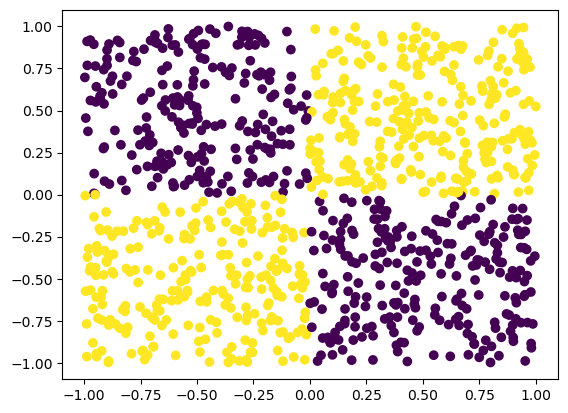

In [34]:
N = 1000
X = rng.uniform(-1,1,(N,2))
Y = np.zeros((N,1))
Y[X[:,0] * X[:,1] > 0] = 1

plt.scatter(X[:,0],X[:,1], c=Y)

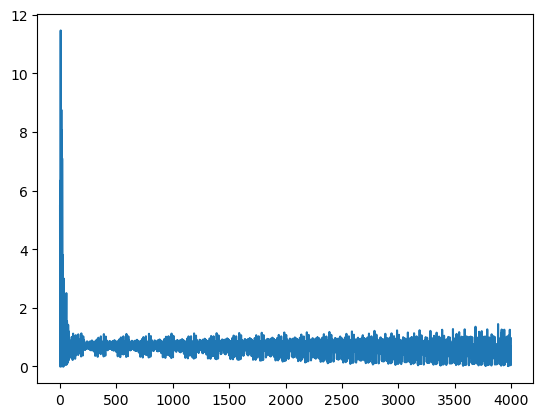

In [52]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.8)

NN = NeuralNetwork([8,4,1], activations = ["relu","relu","sigmoid"])
NN.train(X_train, Y_train, a=0.01, epochs = 20)

plt.plot(NN.loss_history)

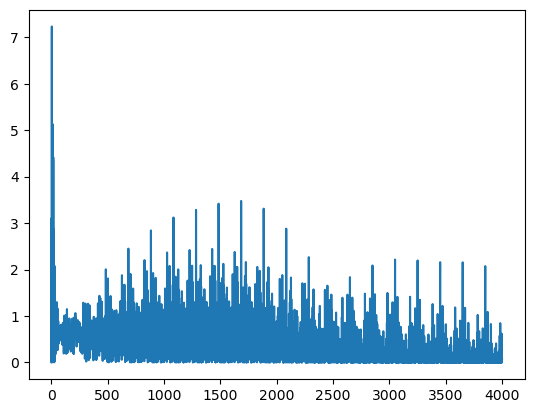

In [55]:
adam_NN = AdamNN([8,4,1], activations = ["relu","relu","sigmoid"])
adam_NN.train(X_train, Y_train, a=0.01, epochs = 20)

plt.plot(adam_NN.loss_history)

Text(0.5, 1.0, 'Adam NN')

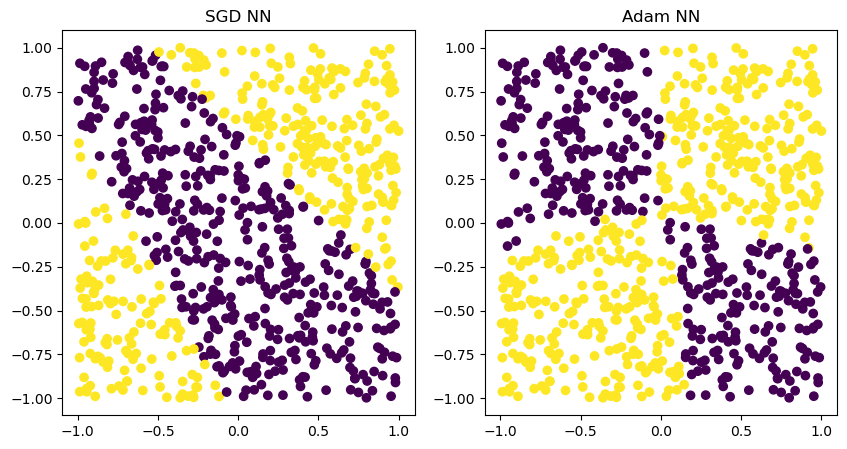

In [56]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))
predictions = [np.round(NN.forward(X_test[i]).val) for i in range(len(Y_test))]
ax1.scatter(X_test[:,0],X_test[:,1], c=predictions)
ax1.set_title("SGD NN")

predictions_adam = [np.round(adam_NN.forward(X_test[i]).val) for i in range(len(Y_test))]
ax2.scatter(X_test[:,0],X_test[:,1], c=predictions_adam)
ax2.set_title("Adam NN")

As we can see, the Adam optimizer converges much faster than SGD. I would guess that the reasons are that Adam uses momentum so if there is ever a flat plane in the loss landscape, it uses the momentum to "roll" through it. Also its adaptive updates make it so the weights that would take a while to get to the correct values get there much faster. Apparently, this is also more robust to different starting weights and aggressive learning rates.